In [1]:
!pip install -q kagglehub geopandas hdbscan folium contextily

In [2]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download(
    "adelanseur/crimes-2001-to-present-chicago"
)

print("Path to dataset files:", path)

# Show downloaded files
print("\nFiles:")
for file in os.listdir(path):
    print(file)

100%|██████████| 436M/436M [00:06<00:00, 73.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/adelanseur/crimes-2001-to-present-chicago/versions/1

Files:
Crimes_-_2001_to_Present.csv


In [3]:
import pandas as pd
import os
import glob

# Find CSV files
csv_files = glob.glob(os.path.join(path, "*.csv"))

print("CSV files found:")
for file in csv_files:
    print(file)

# Load the first CSV
file_path = csv_files[0]
df = pd.read_csv(file_path)

print("\nDataset shape:", df.shape)
df.head()

CSV files found:
/root/.cache/kagglehub/datasets/adelanseur/crimes-2001-to-present-chicago/versions/1/Crimes_-_2001_to_Present.csv

Dataset shape: (7842937, 22)


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,11646166,JC213529,09/01/2018 12:01:00 AM,082XX S INGLESIDE AVE,0810,THEFT,OVER $500,RESIDENCE,False,True,...,8.0,44.0,06,NaN,NaN,2018,04/06/2019 04:04:43 PM,NaN,NaN,NaN
1,11645836,JC212333,05/01/2016 12:25:00 AM,055XX S ROCKWELL ST,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,...,15.0,63.0,11,NaN,NaN,2016,04/06/2019 04:04:43 PM,NaN,NaN,NaN
2,11449702,JB373031,07/31/2018 01:30:00 PM,009XX E HYDE PARK BLVD,2024,NARCOTICS,POSS: HEROIN(WHITE),STREET,True,False,...,5.0,41.0,18,NaN,NaN,2018,04/09/2019 04:24:58 PM,NaN,NaN,NaN
3,11643334,JC209972,12/19/2018 04:30:00 PM,056XX W WELLINGTON AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,31.0,19.0,14,NaN,NaN,2018,04/04/2019 04:16:11 PM,NaN,NaN,NaN
4,11645527,JC212744,02/02/2015 10:00:00 AM,069XX W ARCHER AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,OTHER,False,False,...,23.0,56.0,11,NaN,NaN,2015,04/06/2019 04:04:43 PM,NaN,NaN,NaN


In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Columns:
['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7842937 entries, 0 to 7842936
Data columns (total 22 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Case Number           object 
 2   Date                  object 
 3   Block                 object 
 4   IUCR                  object 
 5   Primary Type          object 
 6   Description           object 
 7   Location Description  object 
 8   Arrest                bool   
 9   Domestic              bool   
 10  Beat                  int64  
 11  District              float64
 12  Ward                  float64
 13  Community Area        float64
 14  FBI Code          

In [5]:
print("Latitude missing values:",
      df["Latitude"].isna().sum())

print("Longitude missing values:",
      df["Longitude"].isna().sum())

print("\nLatitude range:")
print(df["Latitude"].min(), df["Latitude"].max())

print("\nLongitude range:")
print(df["Longitude"].min(), df["Longitude"].max())

Latitude missing values: 88022
Longitude missing values: 88022

Latitude range:
36.619446395 42.022910333

Longitude range:
-91.686565684 -87.524529378


In [6]:
# Keep only required columns
geo_df = df[
    ["ID", "Primary Type", "Date", "Latitude", "Longitude"]
].copy()

# Remove missing coordinates
geo_df = geo_df.dropna(
    subset=["Latitude", "Longitude"]
)

# Remove invalid coordinates
geo_df = geo_df[
    (geo_df["Latitude"] >= -90) &
    (geo_df["Latitude"] <= 90) &
    (geo_df["Longitude"] >= -180) &
    (geo_df["Longitude"] <= 180)
]

print("Original records:", len(df))
print("Clean records:", len(geo_df))

geo_df.head()

Original records: 7842937
Clean records: 7754915


,ID,Primary Type,Date,Latitude,Longitude
6,10224881,CRIMINAL DAMAGE,09/03/2015 06:00:00 PM,41.813999,-87.598138
11,10225155,PUBLIC PEACE VIOLATION,09/05/2015 10:42:00 PM,41.954584,-87.648376
15,10225206,BATTERY,09/06/2015 01:10:00 AM,41.808521,-87.626066
17,10225234,BATTERY,09/06/2015 02:00:00 AM,41.885759,-87.713588
23,10225308,LIQUOR LAW VIOLATION,09/06/2015 02:35:00 AM,41.947100,-87.662116


In [7]:
# Number of points to use
SAMPLE_SIZE = 20000

if len(geo_df) > SAMPLE_SIZE:
    sample_df = geo_df.sample(
        SAMPLE_SIZE,
        random_state=42
    )
else:
    sample_df = geo_df.copy()

print("Points used for clustering:", len(sample_df))

Points used for clustering: 20000


In [8]:
import geopandas as gpd

gdf = gpd.GeoDataFrame(
    sample_df,
    geometry=gpd.points_from_xy(
        sample_df["Longitude"],
        sample_df["Latitude"]
    ),
    crs="EPSG:4326"
)

print(gdf.head())
print("\nCRS:", gdf.crs)

              ID        Primary Type                    Date   Latitude  \
2873915  2195751        PROSTITUTION  06/15/2002 12:30:00 AM  41.917248   
6048768  7097370             BATTERY  08/26/2009 01:00:00 PM  41.776871   
5051992  5439593  DECEPTIVE PRACTICE  02/09/2007 12:00:00 AM  41.897728   
2225695  1359843             ASSAULT  01/30/2001 04:45:00 PM  41.767180   
6101485  7179421           NARCOTICS  10/15/2009 06:59:00 PM  41.839846   

         Longitude                    geometry  
2873915 -87.719526  POINT (-87.71953 41.91725)  
6048768 -87.676278  POINT (-87.67628 41.77687)  
5051992 -87.696756  POINT (-87.69676 41.89773)  
2225695 -87.627628  POINT (-87.62763 41.76718)  
6101485 -87.725650  POINT (-87.72565 41.83985)  

CRS: EPSG:4326


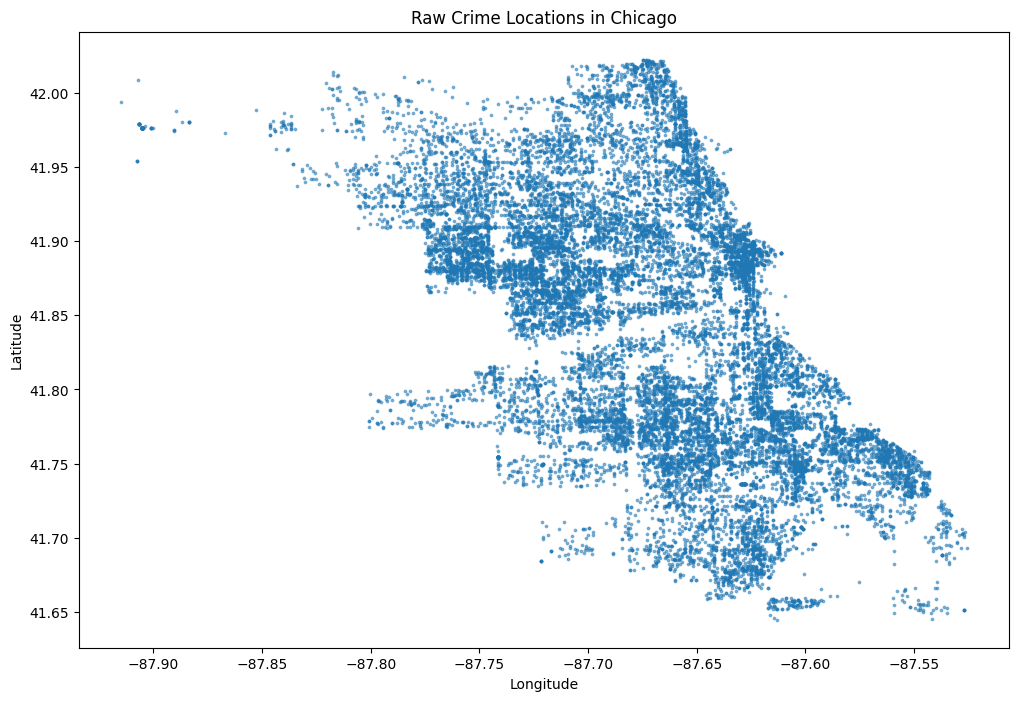

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.scatter(
    gdf["Longitude"],
    gdf["Latitude"],
    s=3,
    alpha=0.5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Raw Crime Locations in Chicago")

plt.show()

In [10]:
import numpy as np
from sklearn.preprocessing import StandardScaler

coordinates = gdf[
    ["Latitude", "Longitude"]
].values

# Scale the coordinates
scaler = StandardScaler()

coordinates_scaled = scaler.fit_transform(
    coordinates
)

print(coordinates_scaled[:5])

[[ 0.86896367 -0.81746228]
 [-0.75938323 -0.07868675]
 [ 0.64253401 -0.42849837]
 [-0.87179053  0.75237765]
 [-0.02887899 -0.92207187]]


In [11]:
from sklearn.cluster import DBSCAN

# DBSCAN parameters
dbscan = DBSCAN(
    eps=0.03,
    min_samples=20
)

dbscan_labels = dbscan.fit_predict(
    coordinates_scaled
)

gdf["DBSCAN_Cluster"] = dbscan_labels

print("DBSCAN completed.")
print(
    "Number of clusters:",
    len(set(dbscan_labels)) -
    (1 if -1 in dbscan_labels else 0)
)

print(
    "Number of anomalies/noise points:",
    list(dbscan_labels).count(-1)
)

DBSCAN completed.
Number of clusters: 101
Number of anomalies/noise points: 14283


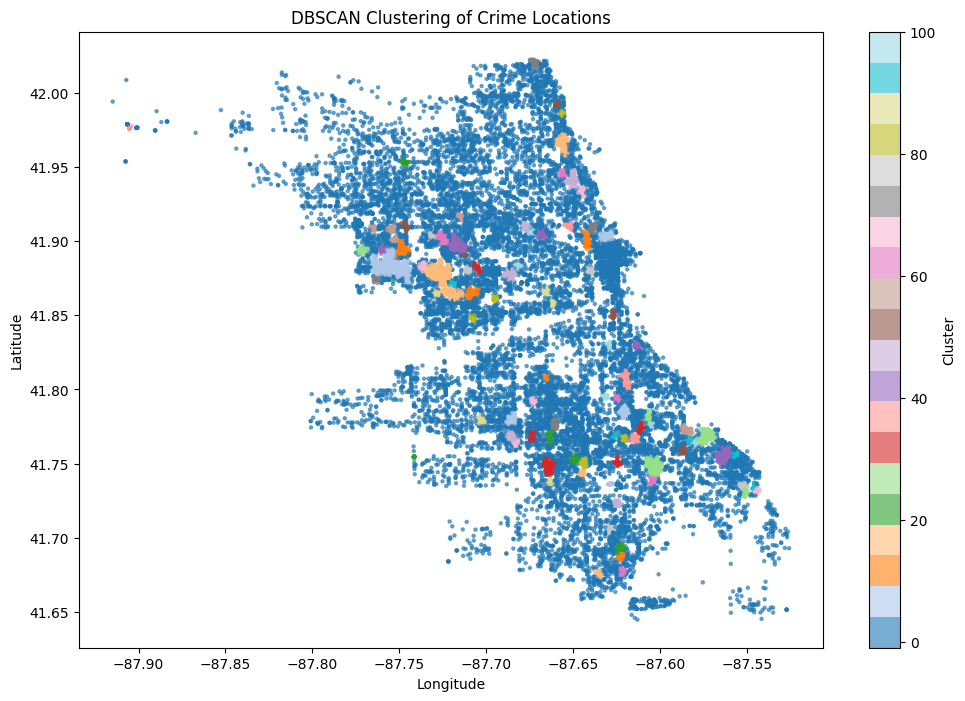

In [12]:
plt.figure(figsize=(12, 8))

plt.scatter(
    gdf["Longitude"],
    gdf["Latitude"],
    c=gdf["DBSCAN_Cluster"],
    s=5,
    alpha=0.6,
    cmap="tab20"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("DBSCAN Clustering of Crime Locations")

plt.colorbar(label="Cluster")

plt.show()

In [13]:
anomalies = gdf[
    gdf["DBSCAN_Cluster"] == -1
].copy()

print("Number of anomalies:", len(anomalies))

anomalies.head()

Number of anomalies: 14283


,ID,Primary Type,Date,Latitude,Longitude,geometry,DBSCAN_Cluster
2873915,2195751,PROSTITUTION,06/15/2002 12:30:00 AM,41.917248,-87.719526,POINT (-87.71953 41.91725),-1
6048768,7097370,BATTERY,08/26/2009 01:00:00 PM,41.776871,-87.676278,POINT (-87.67628 41.77687),-1
5051992,5439593,DECEPTIVE PRACTICE,02/09/2007 12:00:00 AM,41.897728,-87.696756,POINT (-87.69676 41.89773),-1
6101485,7179421,NARCOTICS,10/15/2009 06:59:00 PM,41.839846,-87.725650,POINT (-87.72565 41.83985),-1
5309746,5866519,CRIMINAL DAMAGE,10/27/2007 10:10:00 PM,41.789802,-87.675402,POINT (-87.6754 41.7898),-1


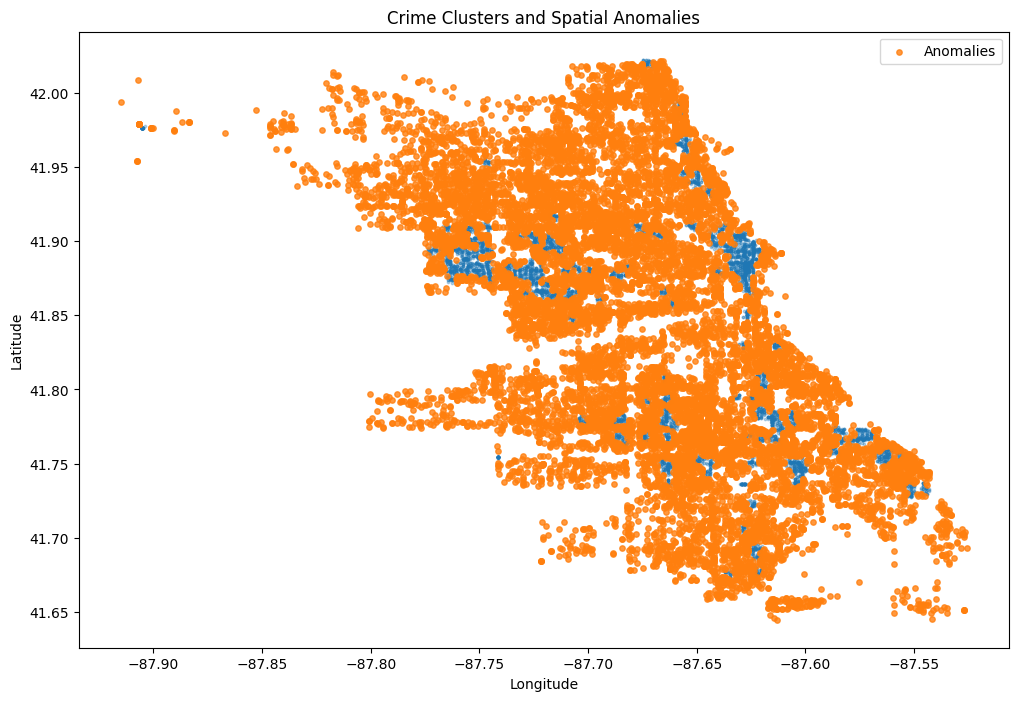

In [14]:
plt.figure(figsize=(12, 8))

# Normal points
normal_points = gdf[
    gdf["DBSCAN_Cluster"] != -1
]

plt.scatter(
    normal_points["Longitude"],
    normal_points["Latitude"],
    s=3,
    alpha=0.3
)

# Anomalies
plt.scatter(
    anomalies["Longitude"],
    anomalies["Latitude"],
    s=15,
    alpha=0.8,
    label="Anomalies"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Crime Clusters and Spatial Anomalies")

plt.legend()

plt.show()

In [15]:
from sklearn.cluster import KMeans

# Number of clusters
K = 5

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(
    coordinates_scaled
)

gdf["KMeans_Cluster"] = kmeans_labels

print("K-Means completed.")
print("Number of clusters:", K)

K-Means completed.
Number of clusters: 5


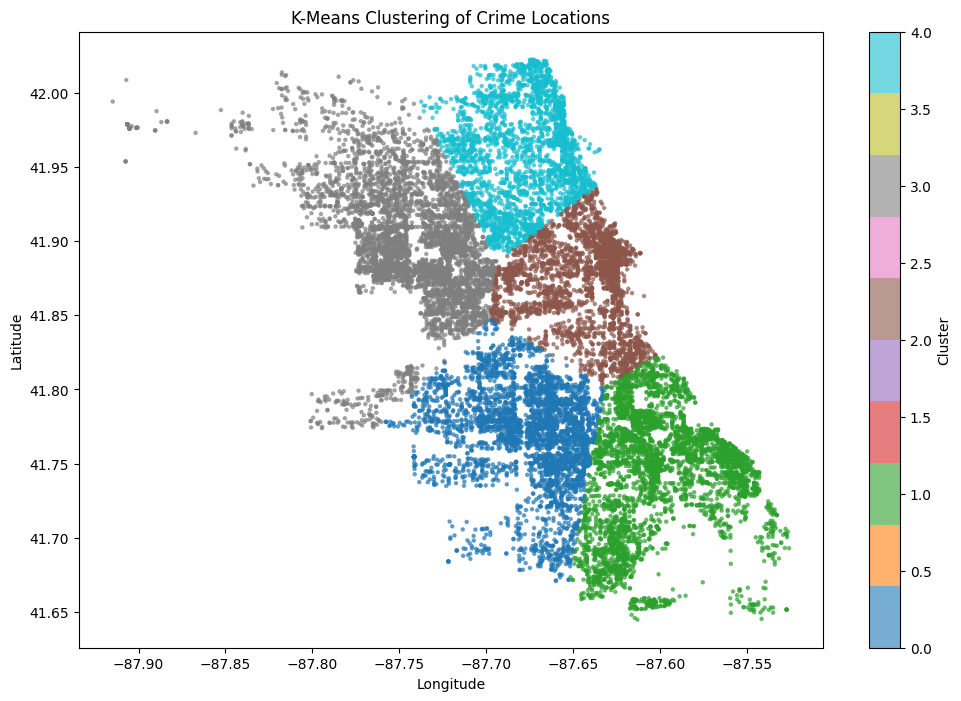

In [16]:
plt.figure(figsize=(12, 8))

plt.scatter(
    gdf["Longitude"],
    gdf["Latitude"],
    c=gdf["KMeans_Cluster"],
    s=5,
    alpha=0.6,
    cmap="tab10"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("K-Means Clustering of Crime Locations")

plt.colorbar(label="Cluster")

plt.show()

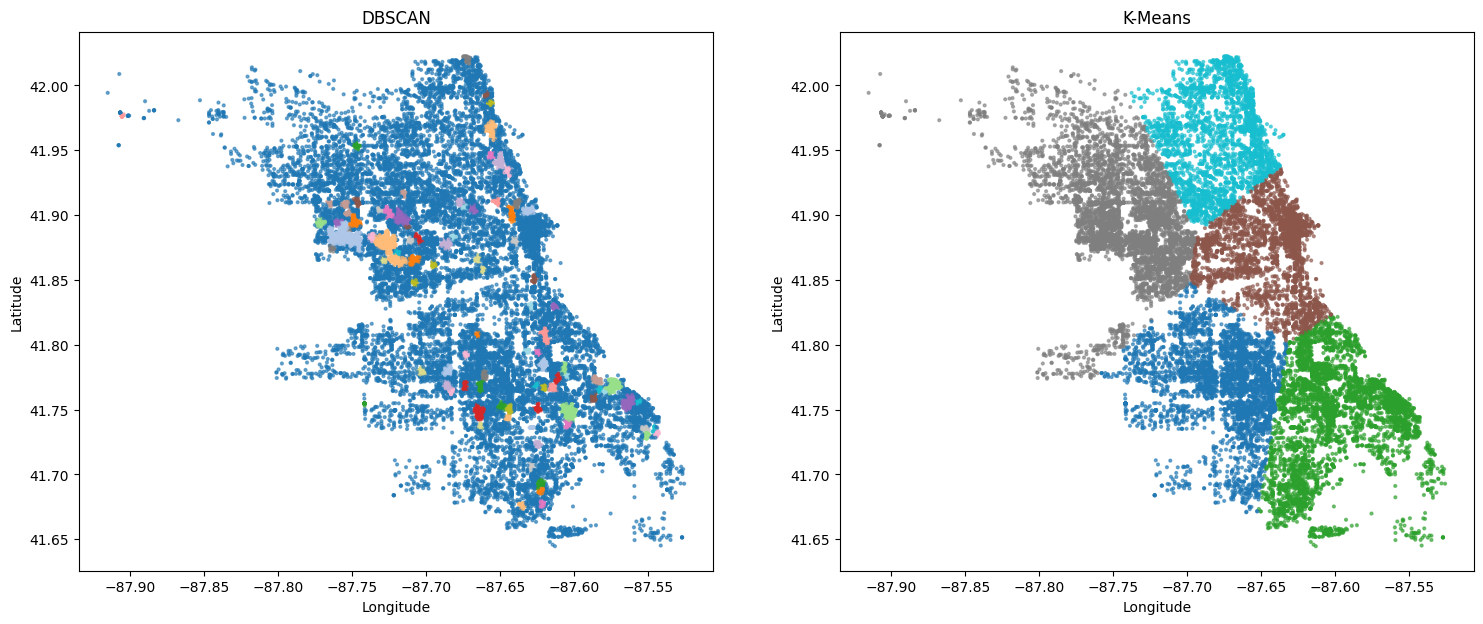

In [17]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 7)
)

# DBSCAN
axes[0].scatter(
    gdf["Longitude"],
    gdf["Latitude"],
    c=gdf["DBSCAN_Cluster"],
    s=4,
    alpha=0.6,
    cmap="tab20"
)

axes[0].set_title("DBSCAN")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# K-Means
axes[1].scatter(
    gdf["Longitude"],
    gdf["Latitude"],
    c=gdf["KMeans_Cluster"],
    s=4,
    alpha=0.6,
    cmap="tab10"
)

axes[1].set_title("K-Means")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.show()

In [18]:
dbscan_clusters = len(
    set(dbscan_labels)
) - (1 if -1 in dbscan_labels else 0)

dbscan_noise = list(dbscan_labels).count(-1)

print("========== DBSCAN ==========")
print("Clusters:", dbscan_clusters)
print("Noise/Anomalies:", dbscan_noise)

print("\n========== K-MEANS ==========")
print("Clusters:", K)
print("Noise detection: Not directly supported")

========== DBSCAN ==========
Clusters: 101
Noise/Anomalies: 14283

========== K-MEANS ==========
Clusters: 5
Noise detection: Not directly supported


In [19]:
import folium

# Center of Chicago
center_lat = gdf["Latitude"].mean()
center_lon = gdf["Longitude"].mean()

crime_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=10
)

# Display a subset so the map remains fast
map_data = gdf.head(3000)

for _, row in map_data.iterrows():

    color = (
        "red"
        if row["DBSCAN_Cluster"] == -1
        else "blue"
    )

    folium.CircleMarker(
        location=[
            row["Latitude"],
            row["Longitude"]
        ],
        radius=2,
        color=color,
        fill=True,
        fill_opacity=0.6
    ).add_to(crime_map)

crime_map

In [20]:
cluster_counts = (
    gdf[gdf["DBSCAN_Cluster"] != -1]
    ["DBSCAN_Cluster"]
    .value_counts()
)

print("Largest DBSCAN clusters:")
print(cluster_counts.head(10))

Largest DBSCAN clusters:
DBSCAN_Cluster
2     831
5     460
16    264
28    187
27    153
41    136
19    128
17    122
1     118
43    116
Name: count, dtype: int64


In [21]:
cluster_crime = pd.crosstab(
    gdf["DBSCAN_Cluster"],
    gdf["Primary Type"]
)

cluster_crime.head()

Primary Type,ARSON,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIM SEXUAL ASSAULT,CRIMINAL DAMAGE,CRIMINAL SEXUAL ASSAULT,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,...,OFFENSE INVOLVING CHILDREN,OTHER OFFENSE,PROSTITUTION,PUBLIC INDECENCY,PUBLIC PEACE VIOLATION,ROBBERY,SEX OFFENSE,STALKING,THEFT,WEAPONS VIOLATION
DBSCAN_Cluster,,,,,,,,,,,,,,,,,,,,,
-1,28,945,2611,927,3,48,1822,10,360,557,...,102,948,137,0,84,516,46,9,2922,198
0,0,5,8,3,0,1,2,0,1,1,...,0,3,0,0,0,0,0,0,3,0
1,0,14,26,9,0,0,13,0,7,2,...,0,7,1,0,1,9,0,0,12,1
2,0,33,86,14,0,0,35,1,48,85,...,1,14,8,0,10,24,2,1,421,2
3,0,1,8,1,0,0,1,0,0,1,...,1,0,1,0,0,0,0,0,3,0


In [22]:
print(
    gdf["Primary Type"]
    .value_counts()
    .head(10)
)

Primary Type
THEFT                  4207
BATTERY                3663
CRIMINAL DAMAGE        2283
NARCOTICS              1914
ASSAULT                1350
OTHER OFFENSE          1204
BURGLARY               1129
MOTOR VEHICLE THEFT     949
DECEPTIVE PRACTICE      815
ROBBERY                 747
Name: count, dtype: int64


In [23]:
output_file = "chicago_crime_clusters.csv"

gdf.drop(
    columns="geometry"
).to_csv(
    output_file,
    index=False
)

print("Saved:", output_file)

Saved: chicago_crime_clusters.csv
